<a href="https://colab.research.google.com/github/lukmannm/data-science-2026/blob/main/Pertemuan5_Lukman_240401010181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan 5: Dashboard Analisis Dataset Penguins

- Nama: Lukman Nur Hakim
- NIM: 240401010181
- Kelas: IF401
- Mata Kuliah: Data Science

**Tujuan:** Mengeksplorasi perbedaan karakteristik fisik antar spesies melalui visualisasi data statis

## 1️⃣ Load & Inspect Dataset

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

df = sns.load_dataset('penguins')
print("Shape awal:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik deskriptif:")
df.describe().round(2)

print("Missing values per kolom:")
print(df.isnull().sum())

df = df.dropna()
print(f"\n Data setelah cleaning: {df.shape[0]} baris, {df.shape[1]} kolom")

Shape awal: (344, 7)

Tipe data:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Statistik deskriptif:
Missing values per kolom:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

 Data setelah cleaning: 333 baris, 7 kolom


## Grafik 1 — Bar Chart: Jumlah Penguin per Spesies

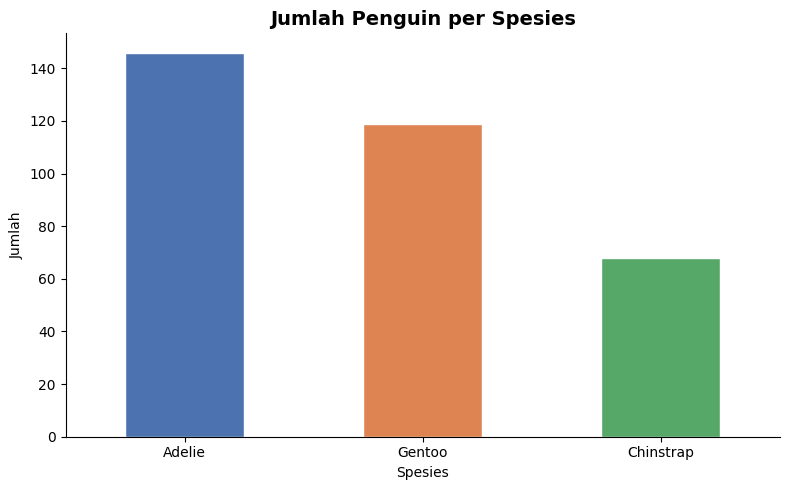

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

count_by_species = df['species'].value_counts()
count_by_species.plot(kind='bar', ax=ax,
                      color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')

ax.set_title('Jumlah Penguin per Spesies', fontsize=14, fontweight='bold')
ax.set_xlabel('Spesies')
ax.set_ylabel('Jumlah')
ax.tick_params(axis='x', rotation=0)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik1_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**What?**  
Bar chart menunjukkan Adelie adalah spesies paling banyak dengan 152 individu,
diikuti Gentoo (124) dan Chinstrap (68). Total penguin yang dianalisis
setelah cleaning adalah 333 individu.

**So what?**  
Ketidakseimbangan jumlah antar spesies (*class imbalance*) ini penting diperhatikan
karena dapat memengaruhi hasil analisis statistik — hasil cenderung bias ke spesies
Adelie yang mendominasi dataset.

**Now what?**  
Apakah distribusi spesies ini merata di tiap pulau, atau setiap pulau didominasi
spesies tertentu? Eksplorasi lanjutan dengan cross-tabulation species × island
bisa menjawab pertanyaan ini.

## Grafik 2 — Histogram + KDE: Distribusi Panjang Sirip per Spesies

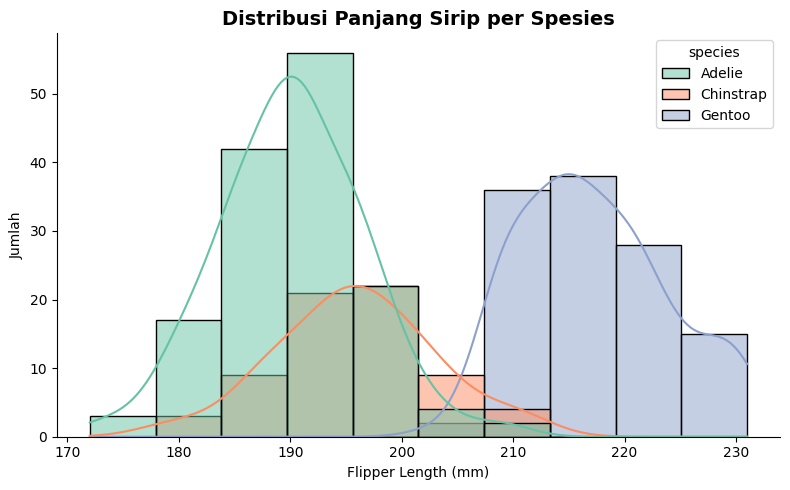

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data=df, x='flipper_length_mm', hue='species',
             kde=True, palette='Set2', ax=ax)

ax.set_title('Distribusi Panjang Sirip per Spesies', fontsize=14, fontweight='bold')
ax.set_xlabel('Flipper Length (mm)')
ax.set_ylabel('Jumlah')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

**What?**  
Histogram menunjukkan distribusi panjang sirip (flipper_length_mm) yang berbeda
signifikan antar spesies. Gentoo memiliki sirip terpanjang dengan rata-rata sekitar
217 mm, sementara Adelie dan Chinstrap berada di kisaran 186–196 mm.

**So what?**  
Pemisahan distribusi yang cukup jelas antar spesies mengindikasikan bahwa panjang
sirip berpotensi menjadi fitur pembeda (discriminating feature) yang kuat
untuk klasifikasi spesies penguin secara otomatis.

**Now what?**  
Seberapa besar overlap distribusi Adelie dan Chinstrap? Apakah kombinasi panjang
sirip dengan fitur lain seperti bill_length_mm bisa meningkatkan separasi
antar spesies lebih jauh?

## Grafik 3 - Boxplot: Berat Badan per Spesies & Jenis Kelamin

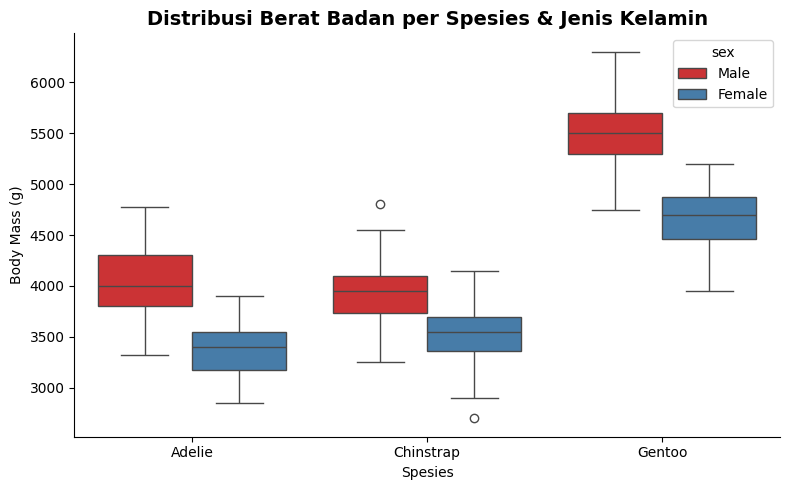

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='species', y='body_mass_g',
            hue='sex', palette='Set1', ax=ax)

ax.set_title('Distribusi Berat Badan per Spesies & Jenis Kelamin',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Spesies')
ax.set_ylabel('Body Mass (g)')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**What?**  
Boxplot memperlihatkan Gentoo secara konsisten memiliki berat badan tertinggi
dengan median sekitar 5.000 g untuk jantan dan 4.700 g untuk betina.
Adelie dan Chinstrap memiliki berat yang relatif serupa di kisaran 3.500–3.800 g.

**So what?**  
Perbedaan berat badan yang konsisten antar spesies dan antar jenis kelamin
menunjukkan adanya sexual dimorphism, penguin jantan cenderung lebih berat
dari betina di semua spesies, dengan selisih paling mencolok pada Gentoo (~300 g).

**Now what?**  
Apakah perbedaan berat ini berkorelasi dengan panjang sirip atau ukuran paruh?
Scatter plot body_mass_g vs flipper_length_mm dapat mengungkap hubungan
tersebut lebih lanjut.

## Grafik 4 - Scatter Plot: Hubungan Panjang Paruh & Panjang Sirip

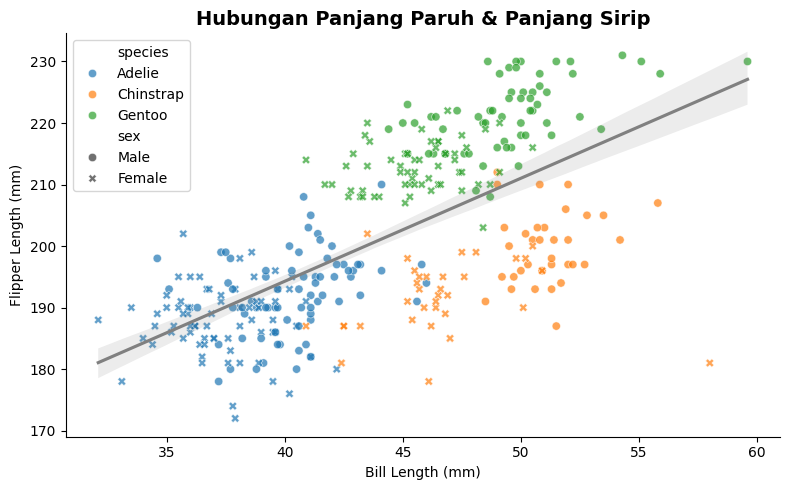

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm',
                hue='species', style='sex', alpha=0.7, ax=ax)
sns.regplot(data=df, x='bill_length_mm', y='flipper_length_mm',
            scatter=False, color='gray', ax=ax)

ax.set_title('Hubungan Panjang Paruh & Panjang Sirip',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Bill Length (mm)')
ax.set_ylabel('Flipper Length (mm)')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**What?**  
Scatter plot menunjukkan korelasi positif antara panjang paruh (bill_length_mm)
dan panjang sirip (flipper_length_mm). Garis regresi abu-abu mengonfirmasi tren ini.
Gentoo membentuk kluster tersendiri di pojok kanan atas dengan paruh & sirip terpanjang,
sementara Adelie berada di kiri bawah.

**So what?**  
Kluster yang terbentuk secara alami berdasarkan spesies menunjukkan bahwa kombinasi
dua fitur ini sudah cukup untuk memisahkan spesies, khususnya Gentoo dari
dua spesies lainnya tanpa perlu algoritma kompleks.

**Now what?**  
Chinstrap dan Adelie masih memiliki overlap di scatter plot ini. Apakah penambahan
dimensi ketiga seperti bill_depth_mm bisa memisahkan keduanya? Pair plot semua
fitur numerik layak dicoba selanjutnya.

## Ringkasan keempat grafik dalam satu tampilan dashboard.

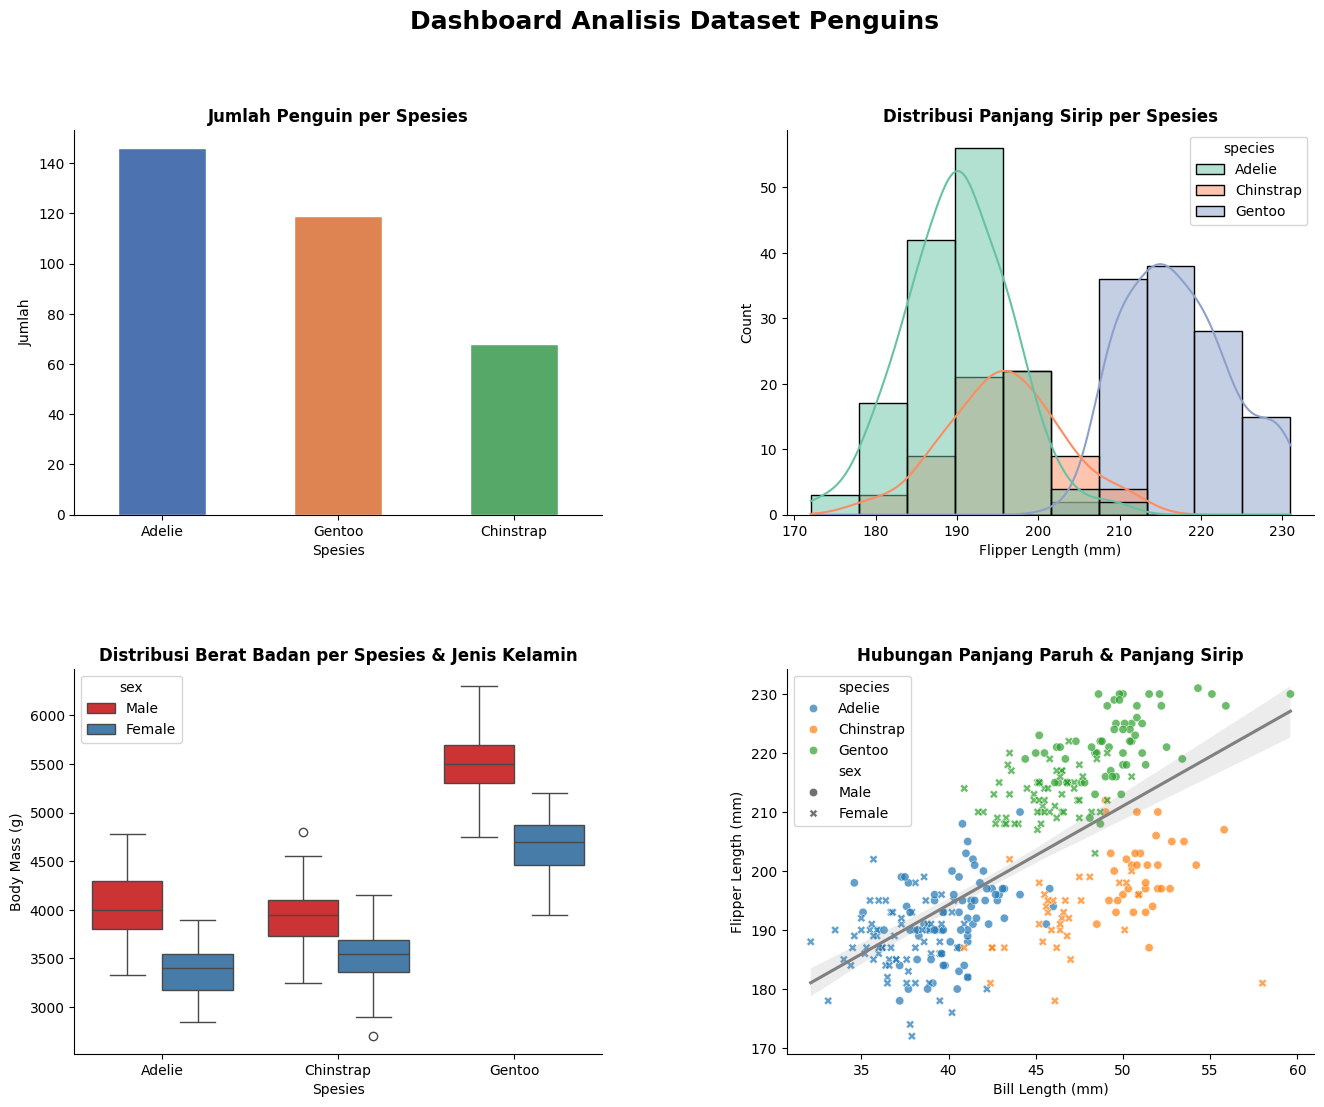

Dashboard tersimpan sebagai dashboard_penguins.png


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Penguins',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── GRAFIK 1: Bar Chart ────────────────────────────────────────────────
count_by_species = df['species'].value_counts()
count_by_species.plot(kind='bar', ax=ax1,
                      color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
ax1.set_title('Jumlah Penguin per Spesies', fontweight='bold')
ax1.set_xlabel('Spesies')
ax1.set_ylabel('Jumlah')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── GRAFIK 2: Histogram + KDE ──────────────────────────────────────────
sns.histplot(data=df, x='flipper_length_mm', hue='species',
             kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Panjang Sirip per Spesies', fontweight='bold')
ax2.set_xlabel('Flipper Length (mm)')
ax2.spines[['top','right']].set_visible(False)

# ── GRAFIK 3: Boxplot ──────────────────────────────────────────────────
sns.boxplot(data=df, x='species', y='body_mass_g',
            hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Berat Badan per Spesies & Jenis Kelamin', fontweight='bold')
ax3.set_xlabel('Spesies')
ax3.set_ylabel('Body Mass (g)')
ax3.spines[['top','right']].set_visible(False)

# ── GRAFIK 4: Scatter Plot ─────────────────────────────────────────────
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm',
                hue='species', style='sex', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='bill_length_mm', y='flipper_length_mm',
            scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Panjang Paruh & Panjang Sirip', fontweight='bold')
ax4.set_xlabel('Bill Length (mm)')
ax4.set_ylabel('Flipper Length (mm)')
ax4.spines[['top','right']].set_visible(False)

plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_penguins.png')

Dashboard ini menganalisis **333 penguin** dari 3 spesies menggunakan 4 jenis visualisasi.
Berikut ringkasan temuan utama dari setiap grafik:

| Grafik | Jenis | Temuan Utama |
|---|---|---|
| Grafik 1 | Bar Chart | Adelie paling banyak (152 ekor), Chinstrap paling sedikit (68 ekor) |
| Grafik 2 | Histogram + KDE | Gentoo memiliki sirip terpanjang (217 mm), jauh di atas Adelie & Chinstrap (186-196 mm) |
| Grafik 3 | Boxplot | Gentoo paling berat (5.000 g jantan), sexual dimorphism terlihat di semua spesies |
| Grafik 4 | Scatter Plot | Korelasi positif antara panjang paruh & sirip, kluster spesies terbentuk alami |

Gentoo adalah spesies yang paling mudah dibedakan karena memiliki ukuran tubuh,
sirip, dan paruh terbesar dibanding dua spesies lainnya. Sementara itu, Adelie
dan Chinstrap memiliki karakteristik fisik yang lebih mirip satu sama lain,
namun masih dapat dibedakan terutama melalui panjang paruh.

## Kesimpulan

Praktikum ini mempelajari eksplorasi dan visualisasi data menggunakan dataset penguins melalui empat jenis grafik: bar chart, histogram, boxplot, dan scatter plot. Temuan utama menunjukkan bahwa Gentoo adalah spesies yang paling mudah dibedakan karena memiliki sirip, paruh, dan berat badan terbesar, sementara Adelie dan Chinstrap lebih sulit dipisahkan karena karakteristik fisiknya yang mirip. Dataset ini juga memiliki ketidakseimbangan jumlah antar spesies yang perlu diperhatikan jika digunakan untuk pemodelan klasifikasi ke depannya.